In [1]:
print("Importing modules...")
from scripts.data_loader import get_data
import pandas as pd
from scripts.database import *
from scripts.analytics import *
from scripts.visualizer import *
from scripts.forecasting import *
from scripts.optimizer import *

print("Loading data...")
# get_data()
data = pd.read_csv("data/historical_data.csv")
print(data.head())

Importing modules...
Loading data...
    symbol       instrument_key   open    high    low    close    volume  \
0  DRREDDY  NSE_EQ|INE089A01031  974.0   974.0  961.2   966.10   5585950   
1  DRREDDY  NSE_EQ|INE089A01031  970.4   977.8  962.2   970.05   6117260   
2  DRREDDY  NSE_EQ|INE089A01031  974.0   987.8  968.5   984.60   5174465   
3  DRREDDY  NSE_EQ|INE089A01031  988.0   992.1  972.4   981.70   6998410   
4  DRREDDY  NSE_EQ|INE089A01031  986.0  1014.8  981.0  1005.80  12029520   

    timestamp  
0  2020-12-01  
1  2020-12-02  
2  2020-12-03  
3  2020-12-04  
4  2020-12-07  


In [2]:
df = data.copy()
df = df[['symbol','open','high','low','close','volume','timestamp']]
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['symbol','timestamp']).reset_index(drop=True)
benchmark, assets = calculate_returns(df)

*Importing and calculating all the metrics.*

### Asset Metrics

In [3]:
asset_returns = assets.pivot(index='timestamp',columns='symbol',values='ret_daily').dropna()
benchmark_returns = benchmark.set_index('timestamp')['ret_daily']
asset_metrics = summary_statistics(asset_returns, benchmark_returns)
eq_weights = pd.Series([0.2, 0.2, 0.2, 0.2, 0.2], index=asset_returns.columns)
print(f"Asset Metrics: \n {asset_metrics}")
store_asset_metrics(asset_metrics)

Asset Metrics: 
                      DRREDDY   HDFCBANK        ITC   RELIANCE        TCS
Mean Daily Return   0.025003   0.028570   0.045159   0.038981   0.020698
Std Dev (Daily)     1.375065   1.334800   1.331860   1.431210   1.307629
Annualised Return   6.300679   7.199708  11.380140   9.823145   5.215895
Annualised Vol     21.828475  21.189292  21.142616  22.719756  20.757964
Skewness           -0.411035   0.054098  -0.327381   0.128420   0.128340
Kurtosis            4.990534   5.516263   5.824245   2.699710   2.366589
Min               -10.496650  -8.432587  -9.714640  -7.481957  -6.353461
Max                 8.130805  10.013280   6.828704   7.017220   6.632770
Sharpe Ratio        0.288645   0.339780   0.538256   0.432361   0.251272
Sortino Ratio       0.388627   0.477976   0.744143   0.658329   0.382002
Beta                0.505729   1.051196   0.693599   1.116199   0.778975
Stored: asset_metrics


In [4]:
portfolio_vol_annual, benchmark_vol_annual, tracking_error, rolling_vol_annual = calculate_vol_tracking(assets, benchmark, eq_weights)
portfolio_sharpe, portfolio_sortino, bench_sharpe, bench_sortino, information_ratio = calculate_risk_metrics(assets, benchmark, eq_weights)
max_drawdown_port, max_drawdown_bench= calculate_drawdown(assets, benchmark, eq_weights)
beta_port = calculate_beta(assets, benchmark, eq_weights)
portfolio_var, portfolio_cvar, portfolio_var_annual, portfolio_cvar_annual = calculate_var(assets, benchmark, eq_weights)
port_folio_skew, port_folio_kurt, bench_skew, bench_kurt = calculate_distribution_metrics(assets, benchmark, eq_weights)
corr_matrix = calculate_corr_metrics(assets, benchmark, eq_weights)
jensens_alpha, r_squared, alpha_skew, alpha_kurt, mean_alpha_stress = calculate_alpha_metrics(assets, benchmark, eq_weights)

### Portfolio Metrics

In [5]:
portfolio_metrics = {
    "sharpe":             float(portfolio_sharpe),
    "sortino":            float(portfolio_sortino),
    "information_ratio":  float(information_ratio),
    "max_drawdown_port":  float(max_drawdown_port),
    "beta":               float(beta_port),
    "var_1d":             float(portfolio_var),
    "cvar_1d":            float(portfolio_cvar),
    "var_annual":         float(portfolio_var_annual),
    "cvar_annual":        float(portfolio_cvar_annual),
    "tracking_error":     float(tracking_error),
    "jensens_alpha":      float(jensens_alpha),
    "r_squared":          float(r_squared),
    "mean_alpha_stress":  float(mean_alpha_stress),
    "alpha_skew":         float(alpha_skew),
    "alpha_kurt":         float(alpha_kurt)
}

print("\nPortfolio Metrics:\n")
for key, value in portfolio_metrics.items():
    print(f"{key}: {value:.2f}")

store_portfolio_metrics(portfolio_metrics)


Portfolio Metrics:

sharpe: 0.60
sortino: 0.88
information_ratio: -0.78
max_drawdown_port: -0.18
beta: 0.83
var_1d: -0.01
cvar_1d: -0.02
var_annual: -0.22
cvar_annual: -0.30
tracking_error: 0.07
jensens_alpha: -0.00
r_squared: 0.75
mean_alpha_stress: 0.00
alpha_skew: -0.07
alpha_kurt: 1.98
Stored: portfolio_metrics


### Benchmark Metrics

In [6]:
benchmark_metrics = {
    "symbol":             "NIFTY",
    "sharpe":             float(bench_sharpe),
    "sortino":            float(bench_sortino),
    "max_drawdown_bench":  float(max_drawdown_bench),
    "bench_skew":         float(bench_skew),
    "bench_kurt":         float(bench_kurt)
}

print("\nBenchmark Metrics:\n")
for key, value in benchmark_metrics.items():
    if key == "symbol":
        print(f"{key}: {value}")
    else:
        print(f"{key}: {value:.2f}")

store_benchmark_metrics(benchmark_metrics)


Benchmark Metrics:

symbol: NIFTY
sharpe: 0.97
sortino: 1.32
max_drawdown_bench: -0.17
bench_skew: -0.39
bench_kurt: 4.18
Stored: benchmark_metrics


Optimizing the equal weight portfolio using mean variance optimizer.

In [7]:
eq_weight_port_returns = asset_returns.dot(eq_weights)
eq_weight_annual_returns = eq_weight_port_returns.mean() * 252
eq_weight_annual_volatility = eq_weight_port_returns.std() * np.sqrt(252)
eq_weight_sharpe = eq_weight_annual_returns/eq_weight_annual_volatility

opt_weights, ret, vol, sharpe = mean_variance_optimizer(asset_returns)
print("\nOptimal Weights:")
print(opt_weights.round(4)*100)
print("\nBefore Optimisation: ")
print(f"\nAnnualised Return: {eq_weight_annual_returns*100:.2f}%")
print(f"Annualised Vol: {eq_weight_annual_volatility*100:.2f}%")
print(f"Sharpe Ratio: {eq_weight_sharpe:.4f}")
print("\nAfter Optimisation: ")
print(f"\nAnnualised Return: {ret*100:.2f}%")
print(f"Annualised Vol: {vol*100:.2f}%")
print(f"Sharpe Ratio: {sharpe:.4f}")

store_optimizer_results(opt_weights, ret, vol, sharpe,
                    eq_weight_annual_returns,
                    eq_weight_annual_volatility,
                    eq_weight_sharpe)


Optimal Weights:
symbol
DRREDDY     14.80
HDFCBANK    14.85
ITC         43.31
RELIANCE    20.41
TCS          6.63
dtype: float64

Before Optimisation: 

Annualised Return: 7.98%
Annualised Vol: 13.36%
Sharpe Ratio: 0.5976

After Optimisation: 

Annualised Return: 9.28%
Annualised Vol: 14.39%
Sharpe Ratio: 0.6449
Stored: optimizer_results


### Plotting all the key metrics

Correlation Matrix

symbol2   DRREDDY  HDFCBANK   ITC  RELIANCE   TCS
symbol1                                          
DRREDDY      1.00      0.14  0.16      0.20  0.24
HDFCBANK     0.14      1.00  0.22      0.36  0.22
ITC          0.16      0.22  1.00      0.31  0.16
RELIANCE     0.20      0.36  0.31      1.00  0.29
TCS          0.24      0.22  0.16      0.29  1.00


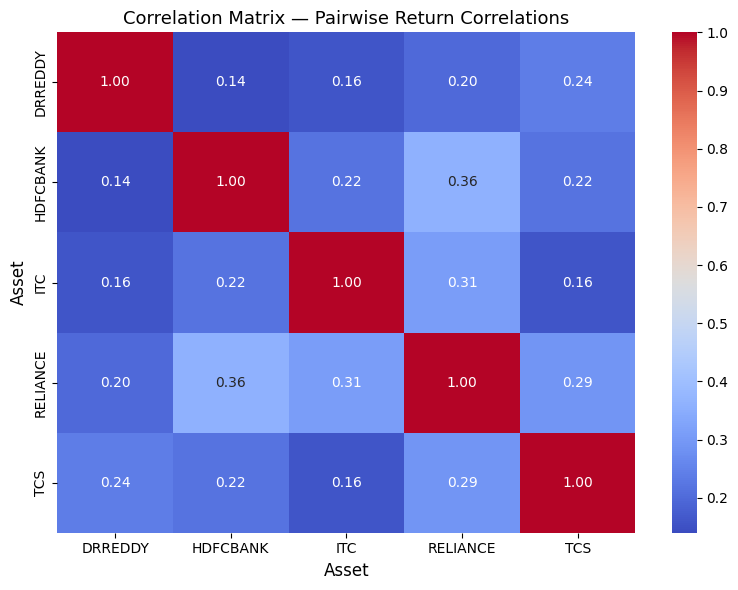

In [8]:

corr_matrix = read_table('corr_matrix')
corr_matrix = corr_matrix.pivot(index='symbol1', columns='symbol2', values='correlation')
print(corr_matrix)
plot_corr(corr_matrix)

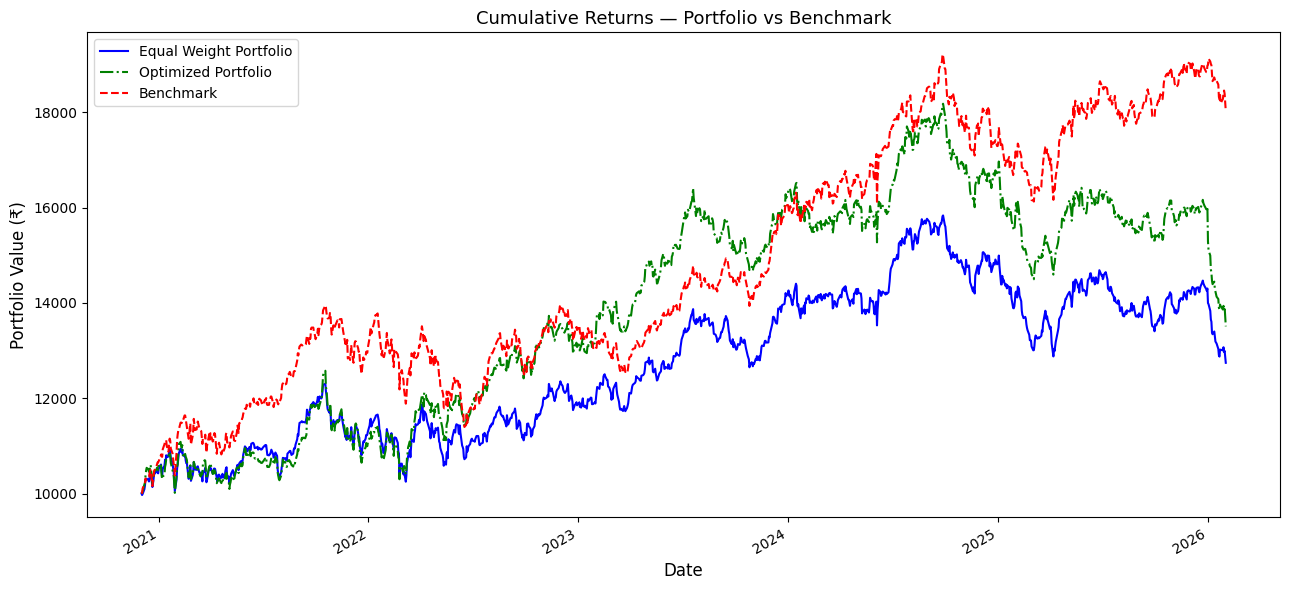

In [9]:
eq_portfolio_returns, optimized_portfolio_returns, benchmark_returns = returns_distribution(eq_weights, opt_weights)
plot_cumulative_returns(eq_portfolio_returns, optimized_portfolio_returns, benchmark_returns)

Plotting Rolling Volatility

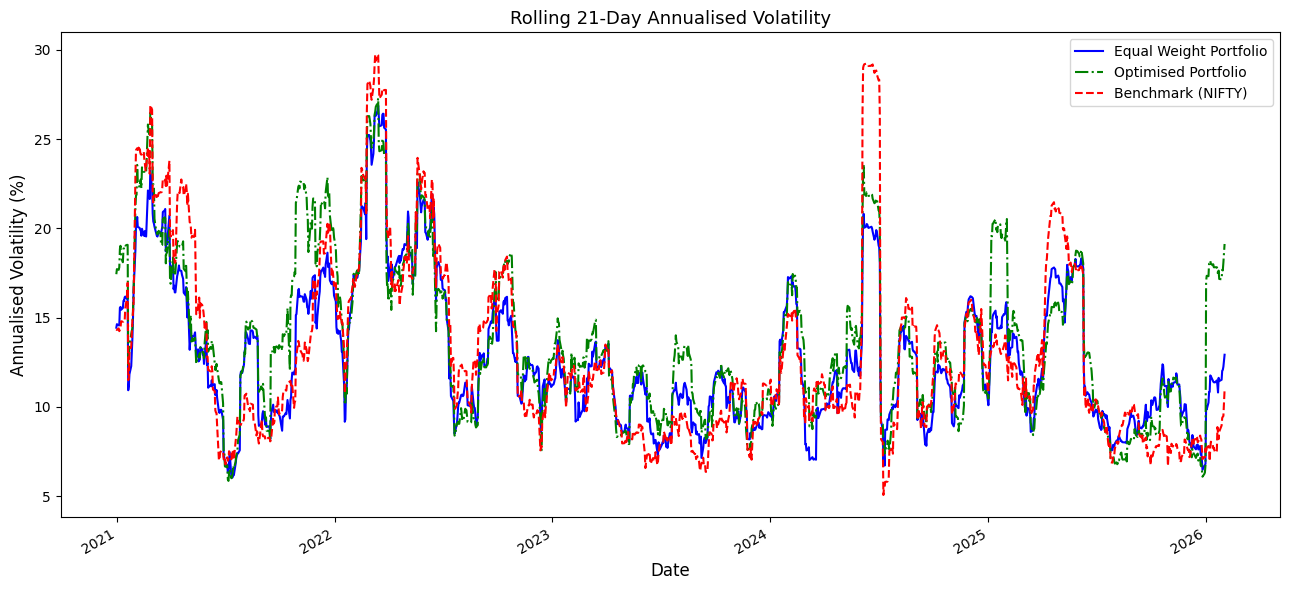

In [10]:
plot_rolling_volatility(eq_portfolio_returns, optimized_portfolio_returns, benchmark_returns)

Plotting Drawdown

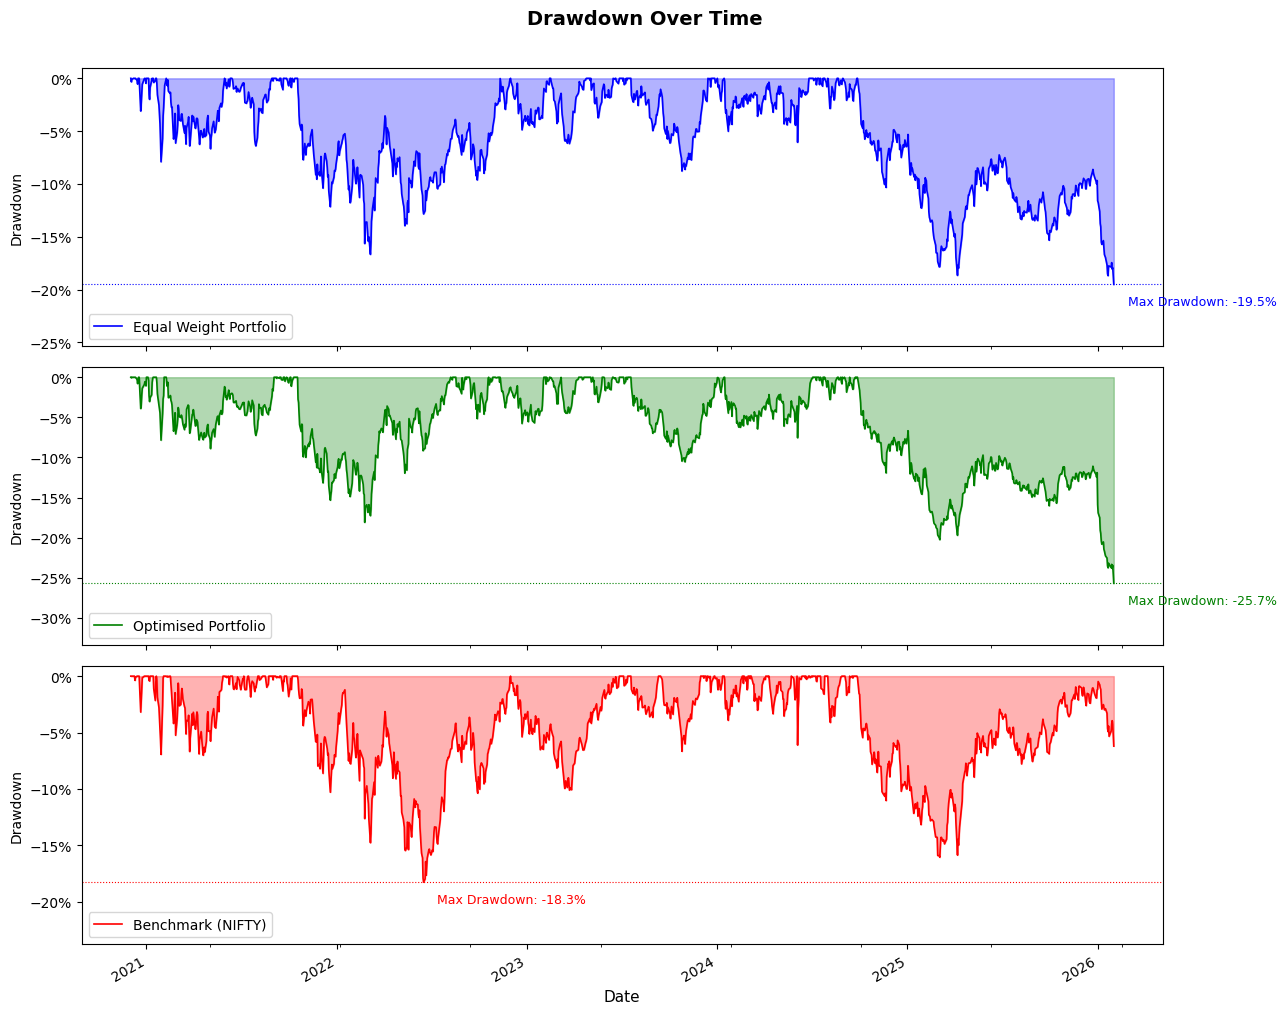

In [11]:
plot_drawdown(eq_portfolio_returns, optimized_portfolio_returns, benchmark_returns)

Plotting Value At Risk (VAR)

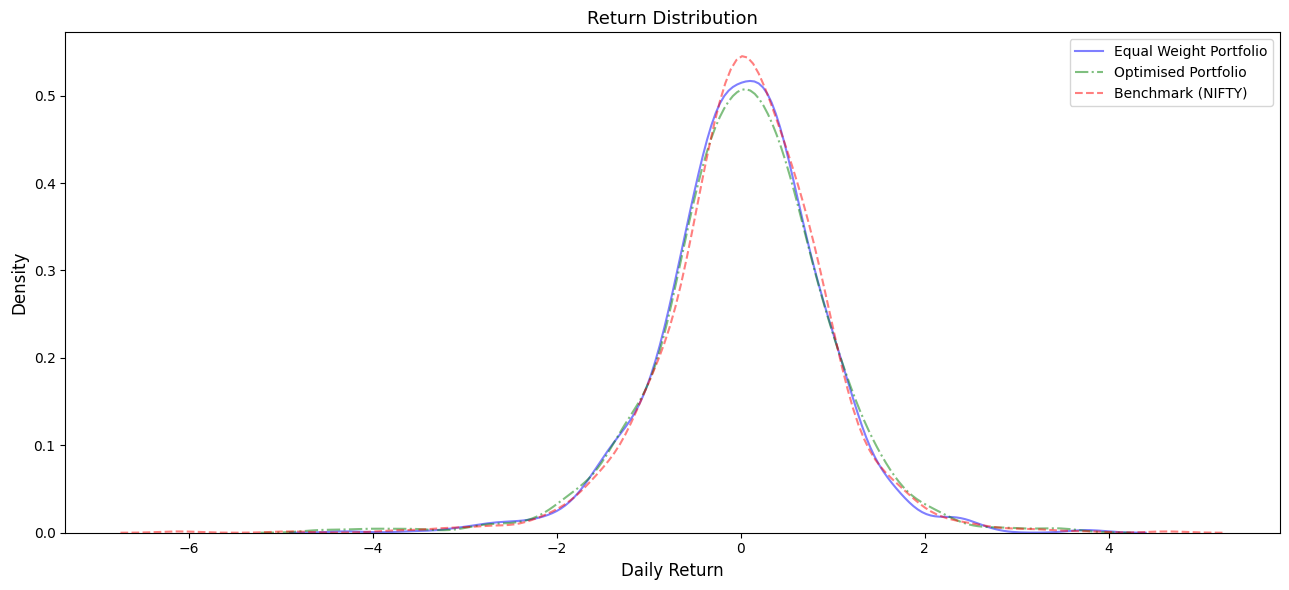

In [12]:
plot_var(eq_portfolio_returns, optimized_portfolio_returns, benchmark_returns)

Plotting weights.

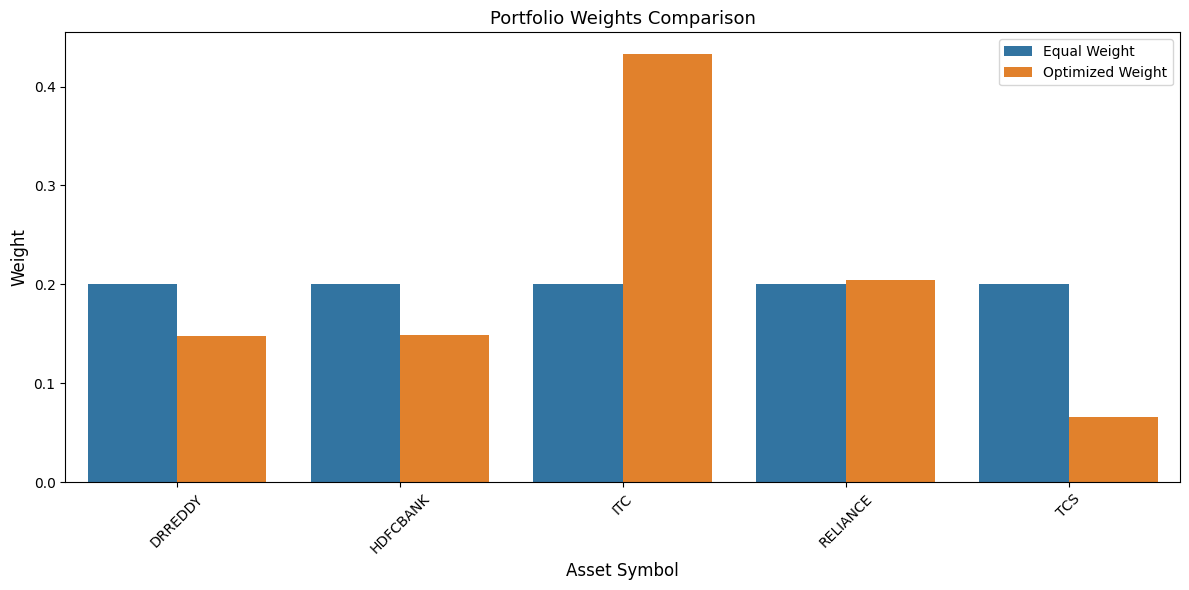

In [13]:
optimizer_results = read_table('optimizer_results')
equal_weights = pd.Series(optimizer_results['equal_weight'].values, index=optimizer_results['symbol'])
optimized_weights = pd.Series(optimizer_results['optimal_weight'].values, index=optimizer_results['symbol'])
plot_weights(equal_weights, optimized_weights)

Plotting Rolling Sharpe

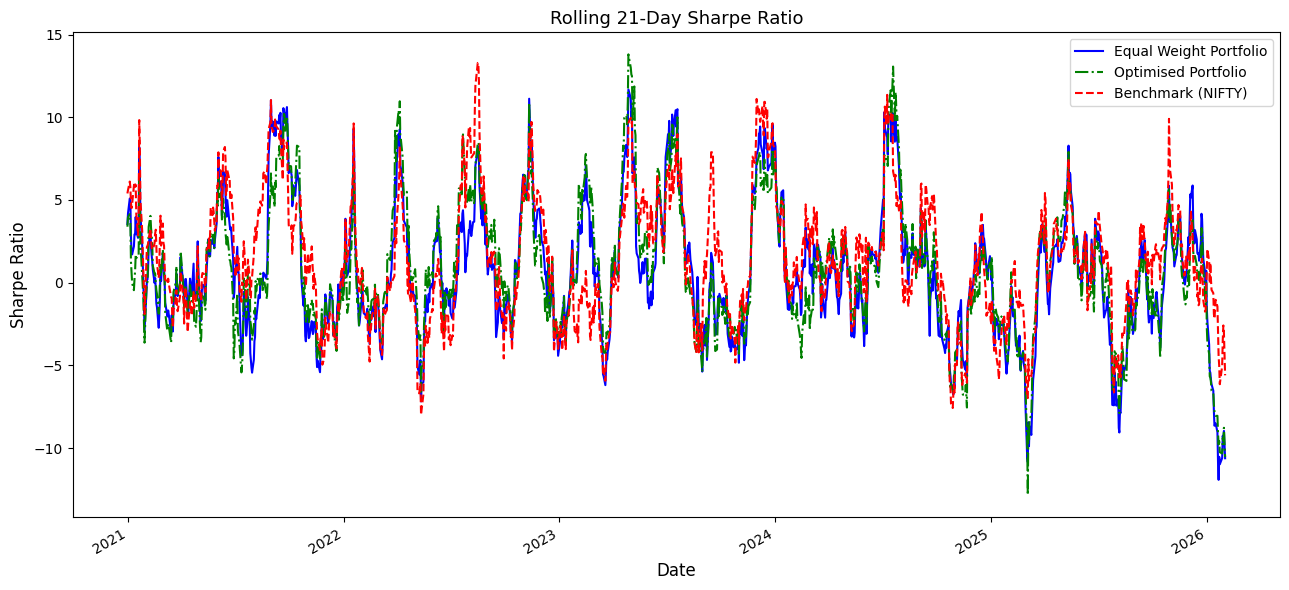

In [14]:
plot_rolling_sharpe(eq_portfolio_returns, optimized_portfolio_returns, benchmark_returns)

Plotting Efficient Frontier for portfolio optimization.

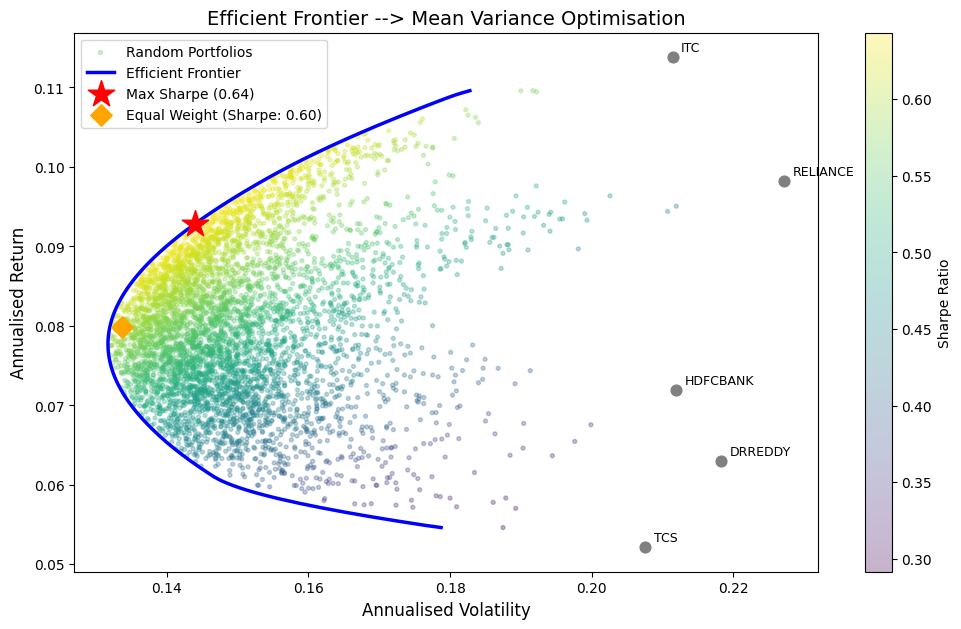

Saved: efficient_frontier.png


In [15]:
plot_efficient_frontier(asset_returns, opt_weights, ret, vol)

Plotting forecast

/home/sriharsha/dev/asst/senda/scripts/forecasting.py:41: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  returns = returns.fillna(method='ffill')


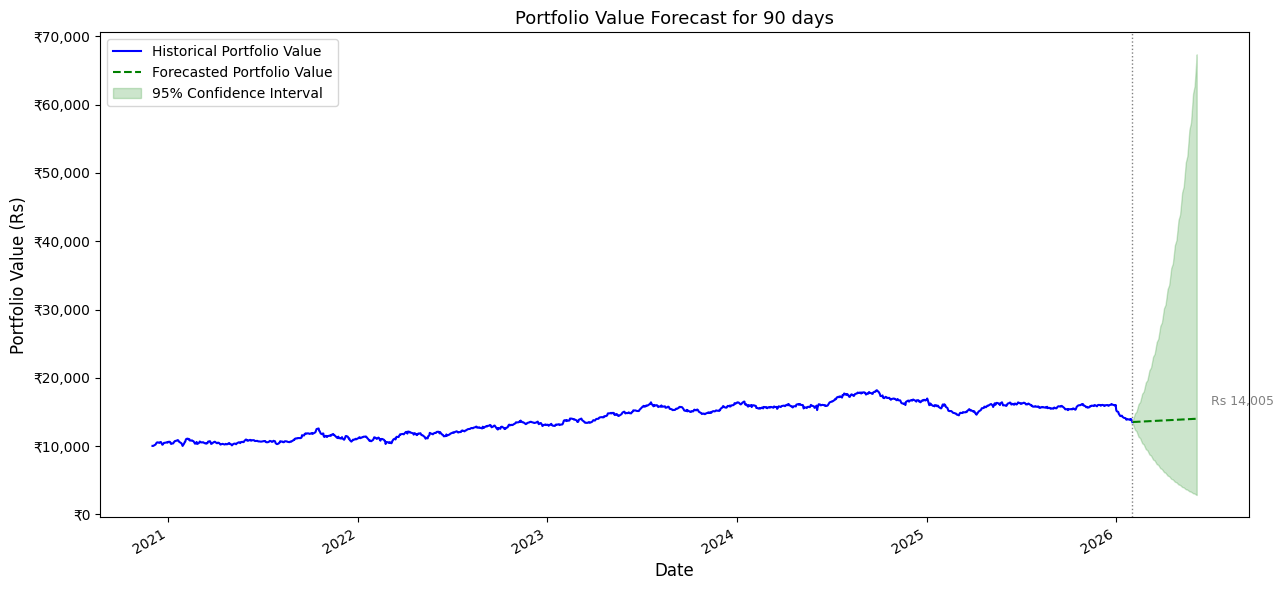

In [16]:
forecast_df = forecast_portfolio_returns(optimized_portfolio_returns)
plot_forecast(optimized_portfolio_returns, forecast_df)